# Machine Learning for Thermal Engineers
## Lesson 9: Introduction to Time Series

Author: Srikantan Natarajan

# 1. Problem Motivation

In Lesson 8, we predicted compressor power from a snapshot of conditions:

TempError, SolarLoad, AmbientTemp → CompressorPower

That model treated every data point as independent. It had no memory of what happened before.

But thermal systems evolve over time. A cabin parked in the sun for 45 minutes behaves very differently from one parked for 5 minutes — even if the current ambient temperature and solar load look identical.

This lesson introduces **time series modeling**: learning from data where the sequence and history of readings matter.

# 2. Three New Ideas

**Autocorrelation**

How similar is a signal to a delayed version of itself? For cabin temperature during a solar soak, the reading at minute 10 is very close to the reading at minute 9. The cabin changes slowly because of thermal mass. This is called high autocorrelation — and it means the recent past is a strong predictor of the near future.

**Lag Features**

A lag feature is the value of a variable at a previous time step, added as a new input column.

Instead of:

T_ambient, SolarLoad → T_cabin

We give the model:

T_cabin_1min_ago, T_ambient, SolarLoad → T_cabin

Now the model knows where the cabin temperature was. It can detect whether the system is heating up or cooling down.

**Rolling Windows**

A rolling window computes the average of the last N readings as a new feature. This smooths out sensor noise and captures the recent trend — is the cabin warming or cooling overall?

Together, lag features and rolling windows give the model a sense of time — something a static regression model simply does not have.

# 3. Engineering Analogy

Thermal engineers already think this way when reading test data.

When you look at a temperature trace, you don't just read the value at one instant — you read the trend. Is it still climbing? Has it leveled off? Is it starting to drop?

Lag features and rolling windows give a machine learning model that same awareness of trajectory — in a form it can learn from.

# 4. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

np.random.seed(42)

# Plot styling — clean, professional, consistent across all charts
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.size': 12,
})

# 5. Data — Solar Soak Scenario

We simulate 90 minutes of cabin temperature data:

- Minutes 0–60: solar soak, cabin heats up
- Minutes 60–90: HVAC turns on, cabin cools down

This gives us a time series with a clear trend — a good starting point for understanding why history matters.

In [2]:
time       = np.arange(0, 90)
T_ambient  = 35 + np.random.normal(0, 0.3, 90)
solar_load = np.where(time < 60, 800, 200)
hvac_on    = np.where(time >= 60, 1, 0)

T_cabin = (
    25
    + 0.35 * np.clip(time, 0, 60)
    - 0.50 * np.clip(time - 60, 0, None)
    + np.random.normal(0, 0.2, 90)
)

df = pd.DataFrame({
    "time_min":   time,
    "T_ambient":  T_ambient,
    "solar_load": solar_load,
    "hvac_on":    hvac_on,
    "T_cabin":    T_cabin
})

df.head()

,time_min,T_ambient,solar_load,hvac_on,T_cabin
0,0,35.149014,800,0,25.019416
1,1,34.958521,800,0,25.543729
2,2,35.194307,800,0,25.559589
3,3,35.456909,800,0,25.984468
4,4,34.929754,800,0,26.321578


# 6. Visualization

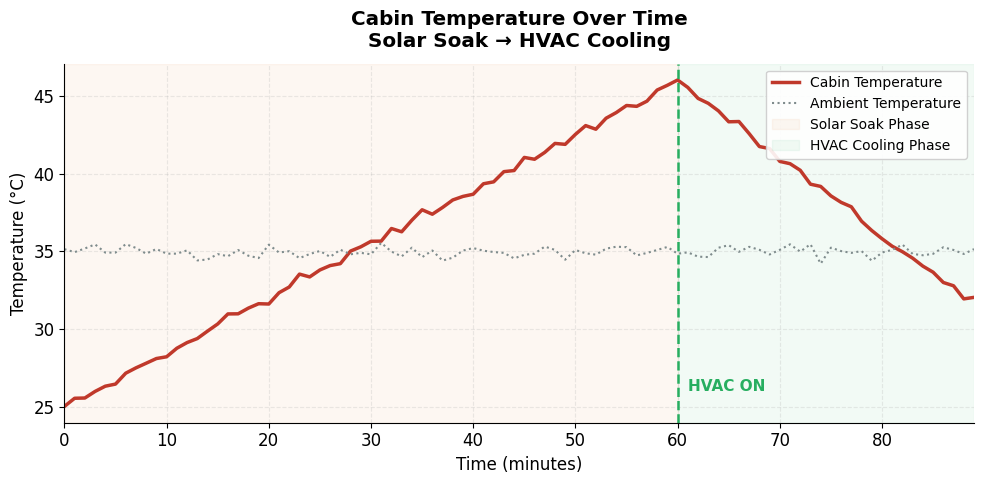

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df.time_min, df.T_cabin, color='#C0392B', linewidth=2.5, label='Cabin Temperature')
ax.plot(df.time_min, df.T_ambient, color='#7F8C8D', linewidth=1.5, linestyle=':', label='Ambient Temperature')

ax.axvspan(0,  60, alpha=0.06, color='#E67E22', label='Solar Soak Phase')
ax.axvspan(60, 89, alpha=0.06, color='#27AE60', label='HVAC Cooling Phase')
ax.axvline(x=60, color='#27AE60', linestyle='--', linewidth=1.8)
ax.text(61, 26, 'HVAC ON', color='#27AE60', fontsize=11, fontweight='bold')

ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Cabin Temperature Over Time\nSolar Soak → HVAC Cooling', fontweight='bold', pad=12)
ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax.set_xlim(0, 89)
plt.tight_layout()
plt.show()

# 7. Autocorrelation

We measure how strongly the current cabin temperature is correlated with its value from 1, 5, and 10 minutes earlier.

A value of 1.0 means perfectly predictable from the past. A value near 0 means the past tells us nothing.

In [4]:
for lag in [1, 5, 10]:
    r = df["T_cabin"].autocorr(lag=lag)
    print(f"Autocorrelation at lag {lag:2d} min: r = {r:.4f}")

Autocorrelation at lag  1 min: r = 0.9966
Autocorrelation at lag  5 min: r = 0.9449
Autocorrelation at lag 10 min: r = 0.7870


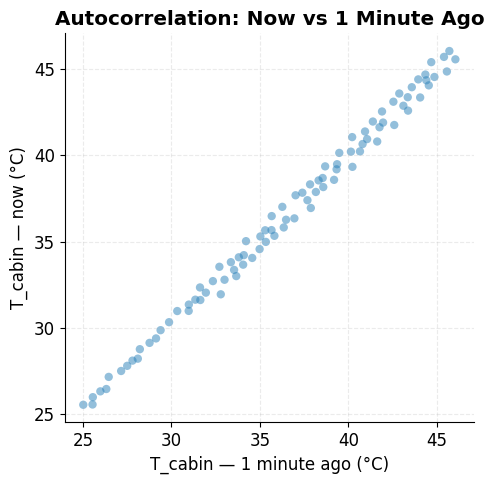

The tight diagonal confirms: where the cabin was 1 minute ago
is a very strong predictor of where it is now.


In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(df['T_cabin'].shift(1), df['T_cabin'], alpha=0.5, color='#2980B9', edgecolors='none')
ax.set_xlabel('T_cabin — 1 minute ago (°C)')
ax.set_ylabel('T_cabin — now (°C)')
ax.set_title('Autocorrelation: Now vs 1 Minute Ago', fontweight='bold')
plt.tight_layout()
plt.show()

print('The tight diagonal confirms: where the cabin was 1 minute ago')
print('is a very strong predictor of where it is now.')

# 8. Creating Lag Features and a Rolling Window

We add three new columns:

- T_cabin_lag1 → cabin temperature 1 minute ago
- T_cabin_lag5 → cabin temperature 5 minutes ago
- T_cabin_roll5 → average cabin temperature over the last 5 minutes

In [6]:
df["T_cabin_lag1"]  = df["T_cabin"].shift(1)
df["T_cabin_lag5"]  = df["T_cabin"].shift(5)
df["T_cabin_roll5"] = df["T_cabin"].shift(1).rolling(window=5).mean()

df = df.dropna().reset_index(drop=True)

df[["time_min", "T_cabin", "T_cabin_lag1", "T_cabin_lag5", "T_cabin_roll5"]].head(10)

,time_min,T_cabin,T_cabin_lag1,T_cabin_lag5,T_cabin_roll5
0,5,26.457297,26.321578,25.019416,25.685756
1,6,27.159224,26.457297,25.543729,25.973332
2,7,27.502211,27.159224,25.559589,26.296431
3,8,27.801023,27.502211,25.984468,26.684956
4,9,28.103083,27.801023,26.321578,27.048267
5,10,28.216926,28.103083,26.457297,27.404567
6,11,28.765871,28.216926,27.159224,27.756493
7,12,29.131457,28.765871,27.502211,28.077823
8,13,29.389545,29.131457,27.801023,28.403672
9,14,29.867743,29.389545,28.103083,28.721376


# 9. Model Training — Static vs Time-Aware

We train two Ridge regression models and compare them:

- **Model A (static):** T_ambient, solar_load, hvac_on only
- **Model B (time-aware):** same inputs plus lag features and rolling window

Both models predict T_cabin one minute into the future.

Important: for time series, we never shuffle the train/test split. We train on earlier data and test on later data — the same way the model would be used in practice.

In [8]:
df["target"] = df["T_cabin"].shift(-1)
df = df.dropna()

split   = int(0.7 * len(df))
y_train = df["target"].values[:split]
y_test  = df["target"].values[split:]

# Model A: static features only
cols_A   = ["T_ambient", "solar_load", "hvac_on"]
scaler_A = StandardScaler()
model_A  = Ridge(alpha=1.0)
model_A.fit(scaler_A.fit_transform(df[cols_A].values[:split]), y_train)
pred_A   = model_A.predict(scaler_A.transform(df[cols_A].values[split:]))

print("Model A (static) MAE:", round(mean_absolute_error(y_test, pred_A), 3), "°C")

Model A (static) MAE: 7.314 °C


In [9]:
# Model B: static + lag + rolling features
cols_B   = ["T_ambient", "solar_load", "hvac_on", "T_cabin_lag1", "T_cabin_lag5", "T_cabin_roll5"]
scaler_B = StandardScaler()
model_B  = Ridge(alpha=1.0)
model_B.fit(scaler_B.fit_transform(df[cols_B].values[:split]), y_train)
pred_B   = model_B.predict(scaler_B.transform(df[cols_B].values[split:]))

mae_A = mean_absolute_error(y_test, pred_A)
mae_B = mean_absolute_error(y_test, pred_B)

print("Model A (static)     MAE:", round(mae_A, 3), "°C")
print("Model B (time-aware) MAE:", round(mae_B, 3), "°C")
print("Improvement:", round(mae_A - mae_B, 3), "°C")

Model A (static)     MAE: 7.314 °C
Model B (time-aware) MAE: 1.88 °C
Improvement: 5.434 °C


# 10. Visualization

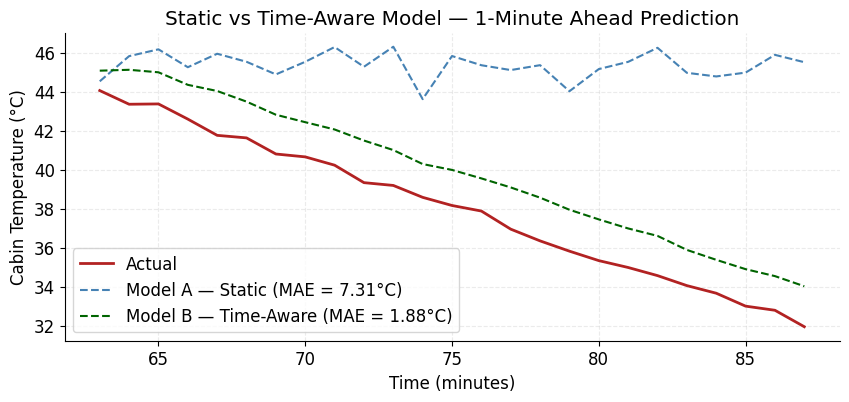

In [10]:
time_test = df["time_min"].values[split:]

plt.figure(figsize=(10, 4))
plt.plot(time_test, y_test,  color="firebrick", linewidth=2,   label="Actual")
plt.plot(time_test, pred_A,  color="steelblue", linewidth=1.5, linestyle="--", label=f"Model A — Static (MAE = {mae_A:.2f}°C)")
plt.plot(time_test, pred_B,  color="darkgreen", linewidth=1.5, linestyle="--", label=f"Model B — Time-Aware (MAE = {mae_B:.2f}°C)")
plt.xlabel("Time (minutes)")
plt.ylabel("Cabin Temperature (°C)")
plt.title("Static vs Time-Aware Model — 1-Minute Ahead Prediction")
plt.legend()
plt.grid(True)
plt.show()

time_test = df['time_min'].values[split:]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(time_test, y_test, color='#C0392B', linewidth=2.5, label='Actual Cabin Temp')
ax.plot(time_test, pred_A, color='#2980B9', linewidth=2, linestyle='--',
        label=f'Static Model  (MAE = {mae_A:.2f}°C)')
ax.plot(time_test, pred_B, color='#27AE60', linewidth=2, linestyle='--',
        label=f'Time-Aware Model  (MAE = {mae_B:.2f}°C)')

# Annotate the gap between models
mid = len(time_test) // 2
ax.annotate('', xy=(time_test[mid], pred_B[mid]), xytext=(time_test[mid], pred_A[mid]),
            arrowprops=dict(arrowstyle='<->', color='#8E44AD', lw=1.8))
ax.text(time_test[mid] + 0.5, (pred_A[mid] + pred_B[mid]) / 2,
        'Gap', color='#8E44AD', fontsize=10, va='center')

ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Cabin Temperature (°C)')
ax.set_title('Static vs Time-Aware Model\n1-Minute Ahead Cabin Temperature Prediction',
             fontweight='bold', pad=12)
ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax.set_xlim(time_test[0], time_test[-1])
plt.tight_layout()
plt.show()

# 12. Limitations

- This model uses synthetic data with simplified dynamics
- Lag features work well for 1-step ahead prediction but accumulate error over longer horizons
- Real cabin temperature is influenced by occupant presence, door events, and solar angle — none of which are captured here
- Ridge regression with lag features is a starting point — not a production forecasting model

Future lessons will address longer-horizon forecasting with ARIMA (Lesson 10) and sequence models like LSTM (Lesson 12).

# 13. Key Takeaway

Thermal systems have memory. The past state of the system carries information that a snapshot of current conditions alone cannot provide.

- Autocorrelation measures how much the past predicts the future
- Lag features give a model access to recent history
- Rolling windows capture trend and reduce noise
- A time-aware model consistently outperforms a static model on sequential thermal data
- Always split time series by time — never shuffle